
# Lab 22: Variability of Sample Means



In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [58]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore')

# 1. Variability of the Sample Mean

By the [Central Limit Theorem](https://www.inferentialthinking.com/chapters/14/4/Central_Limit_Theorem.html), the probability distribution of the mean or sum of a large random sample is roughly normal. The bell curve is centered at the population mean. Some of the sample means are higher and some are lower, but the deviations from the population mean are roughly symmetric on either side, as we have seen repeatedly.

In our simulations, we also noticed that the means of larger samples tend to be more tightly clustered around the mean of the distribution we sample from, compared if we had smaller samples. Note that in this lab, the data we have access to and sample from is the population (which we rarely have access to), while when we bootstrap, the distribution we sample from is our original sample.

In this section, we will quantify the [variability of the sample mean](https://www.inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html) and develop a relation between the variability and the sample size.

Let's take a look at the salaries of employees of the City of San Francisco in 2014. The mean salary reported by the city government was about $75,463.92. **Note that in this lab, this dataset is the population.**

_Note: If you get stuck on any part of this lab, please refer to [Chapter 14 of the textbook](https://www.inferentialthinking.com/chapters/14/Why_the_Mean_Matters.html)._


In [59]:
salaries = Table.read_table('./DS/sf_salaries_2014.csv').select("salary")
salaries.show(5)

salary
471953
390112
339654
326717
326233


In [60]:
salary_mean = np.mean(salaries.column('salary'))
print('Mean salary of San Francisco city employees in 2014: ', salary_mean.round(2))

Mean salary of San Francisco city employees in 2014:  75463.92


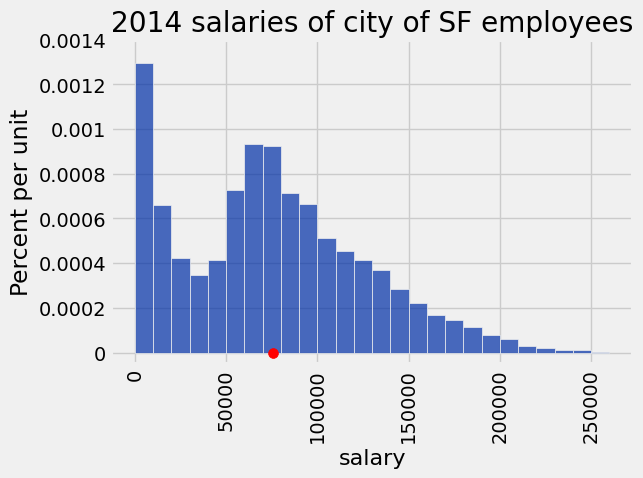

In [61]:
salaries.hist('salary', bins=np.arange(0, 250000+10000*2, 10000))
plots.scatter(salary_mean, 0, color='red', zorder=2, s=50)
plots.title('2014 salaries of city of SF employees')
plots.ylim(-0.0000005, 0.000014);

Clearly, the population _does not_ follow a normal distribution. Keep that in mind as we progress through these exercises.

Let's take random samples **with replacement** and look at the probability distribution of the sample mean. As usual, we will use simulation to get an empirical approximation to this distribution.


**Question 1.1.** Define a function `one_sample_mean`. Its arguments should be `table` (the name of a table), `label` (the label of the column containing the variable), and `sample_size`(the number of employees in the sample). It should sample with replacement from the table and
return the mean of the `label` column of the sample.

_Note:_ The function should reference the arguments and be able to work with any table.


In [62]:
def one_sample_mean(table, label, sample_size):
    new_sample = table.sample(sample_size)
    new_sample_mean = np.mean(new_sample.column(label))
    return new_sample_mean

**Question 1.2.** Use `one_sample_mean` to define a function `simulate_sample_mean`. The arguments are the name of the `table`, the `label` of the column containing the variable, the `sample_size`, and the number of simulations (`repetitions`).

The function should sample with replacement from the table and calculate the mean of each sample. It should save the sample means in an array called `means`. The remaining code in the function displays an empirical histogram of the sample means.

_Note:_ We round all values to 2 decimal places in the provided code because we are working with salaries.


In [63]:
import numpy as np
from datascience import *

"""Empirical distribution of random sample means"""

def simulate_sample_mean(table, label, sample_size, repetitions):

    means = make_array()

    for i in np.arange(repetitions):
        new_sample_mean = one_sample_mean(table, label, sample_size)
        means = np.append(means, new_sample_mean)

    sample_means = Table().with_column('Sample Means', means)

    # Display empirical histogram and print all relevant quantities – don't change this!
    sample_means.hist(bins=20)
    plots.xlabel('Sample Means')
    plots.title('Sample Size {sample_size}; {repetitions} Resamples'.format(sample_size=sample_size, repetitions=repetitions))
    print("Sample size: ", sample_size)
    print("Population mean:", np.mean(table.column(label)).round(2))
    print("Average of sample means: ", np.mean(means).round(2))
    print("Population SD:", np.std(table.column(label)).round(2))
    print("SD of sample means:", np.std(means).round(2))
    return np.std(means)

Verify with a peer that you've implemented the function above correctly. If you haven't implemented it correctly, the rest of the lab won't work properly, so this step is crucial.


In the following cell, we will create a sample of size 100 from `salaries` and graph it using our new `simulate_sample_mean` function.

_Hint: You should see a distribution similar to something we've been talking about. If not, check your function._


Sample size:  100
Population mean: 75463.92
Average of sample means:  75394.19
Population SD: 51697.03
SD of sample means: 5257.19


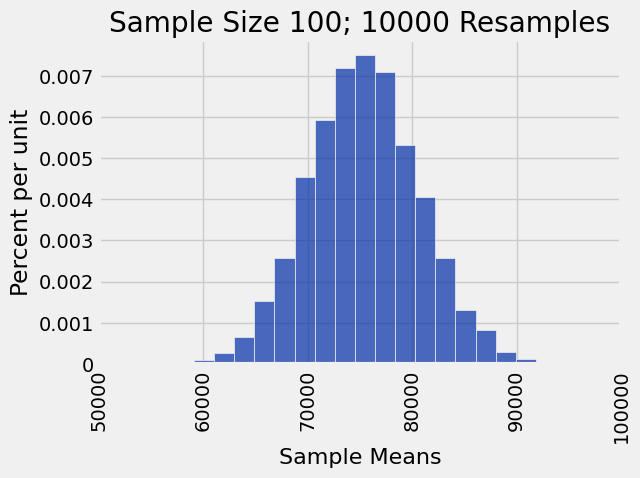

In [64]:
simulate_sample_mean(salaries, 'salary', 100, 10000)
plots.xlim(50000, 100000);

Notice that our distribution of _sample means_ looks approximately normal! Did it matter if our original distribution was normally distributed?


**Question 1.3.** Simulate two sample means, one for a sample of 400 salaries and one for a sample of 625 salaries. In each case, perform 10,000 repetitions. Don't worry about the `plots.xlim` or `plots.ylim` lines – they just make sure that all of the plots have the same x-axis and y-axis, respectively.


Sample size:  400
Population mean: 75463.92
Average of sample means:  75470.24
Population SD: 51697.03
SD of sample means: 2591.14


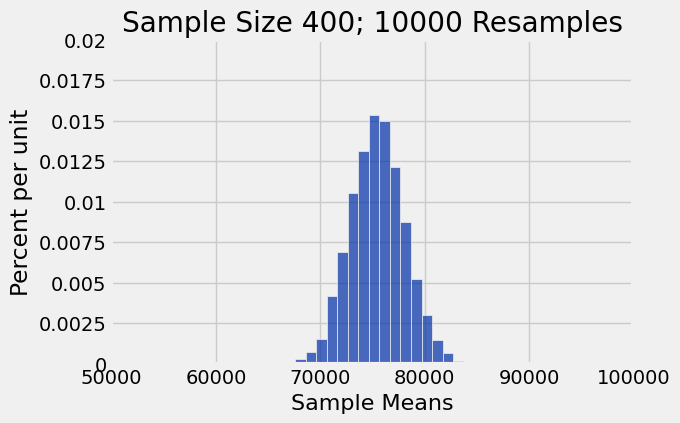



Sample size:  625
Population mean: 75463.92
Average of sample means:  75441.41
Population SD: 51697.03
SD of sample means: 2066.17


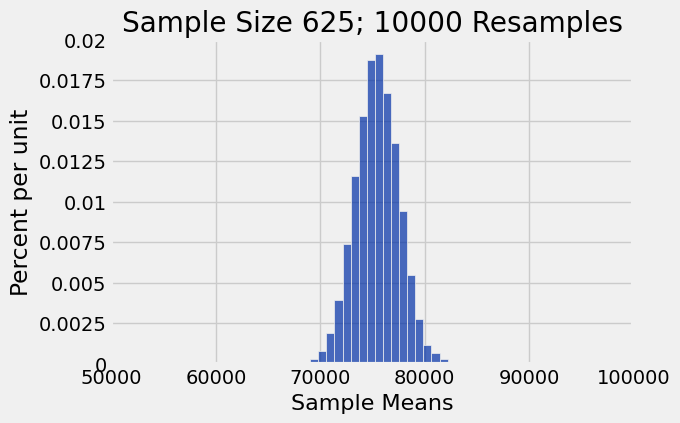

In [65]:
simulate_sample_mean(salaries, 'salary', 400, 10000)
plots.xlim(50000, 100000)
plots.ylim(0, 0.0002)
plots.show();
print('\n')
simulate_sample_mean(salaries, 'salary', 625, 10000)
plots.xlim(50000, 100000)
plots.ylim(0, 0.0002)
plots.show();

**Question 1.4.** Assign `q1_4` to an array of numbers corresponding to true statement(s) about the plots from 1.3.

_Hint_: If a distribution is bell-shaped, what type of curve does it follow?

1. We see the Central Limit Theorem (CLT) in action because the distributions of the sample means are bell-shaped.
2. We see the Law of Averages in action because the distributions of the sample means look like the distribution of the population.
3. One of the conditions for CLT is that we have to draw a small random sample with replacement from the population.
4. One of the conditions for CLT is that we have to draw a large random sample with replacement from the population.
5. One of the conditions for CLT is that the population must be normally distributed.


In [66]:
q1_4 = np.array([1, 4])

**Question 1.5.** Assign `q1_5` to an array of numbers corresponding to true statement(s) about the plots from 1.3.

1. Both plots in 1.3 are roughly centered around the population mean.
2. Both plots in 1.3 are roughly centered around the mean of a particular sample.
3. The distribution of sample means for sample size 625 has less variability than the distribution of sample means for sample size 400.
4. The distribution of sample means for sample size 625 has more variability than the distribution of sample means for sample size 400.


In [67]:
q1_5 = np.array([1, 3])

Below, we'll look at what happens when we take an **increasing number of resamples of a fixed sample size.** Notice what number in the code changes, and what stays the same. How does the distribution of the resampled means change?


Sample size:  100
Population mean: 75463.92
Average of sample means:  75731.24
Population SD: 51697.03
SD of sample means: 5100.25


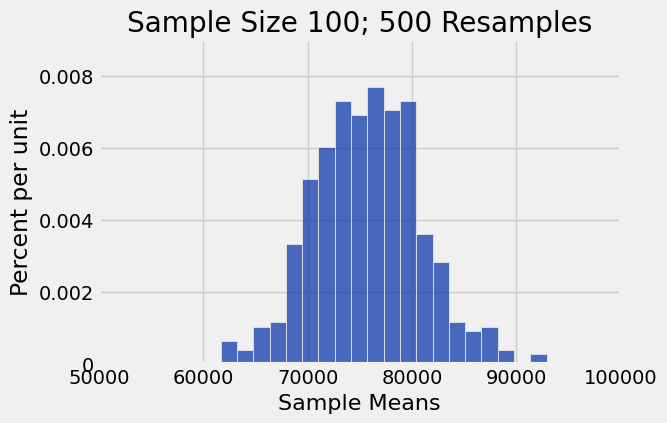

In [68]:
simulate_sample_mean(salaries, 'salary', 100, 500)
plots.xlim(50000, 100000)
plots.ylim(0, 0.00009);

Sample size:  100
Population mean: 75463.92
Average of sample means:  75549.87
Population SD: 51697.03
SD of sample means: 5211.89


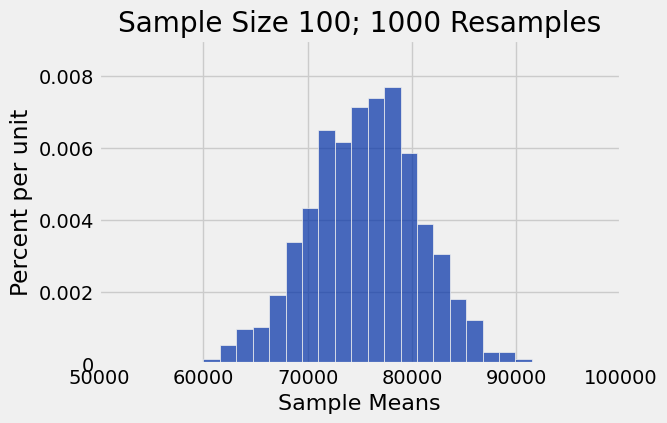

In [69]:
simulate_sample_mean(salaries, 'salary', 100, 1000)
plots.xlim(50000, 100000);
plots.ylim(0, 0.00009);

Sample size:  100
Population mean: 75463.92
Average of sample means:  75557.8
Population SD: 51697.03
SD of sample means: 5202.71


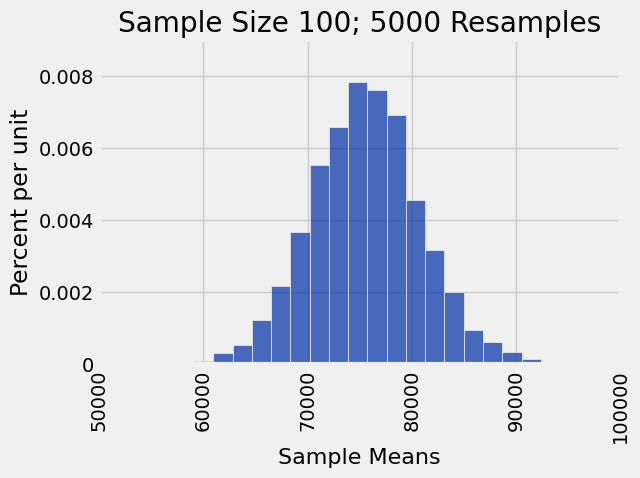

In [70]:
simulate_sample_mean(salaries, 'salary', 100, 5000)
plots.xlim(50000, 100000);
plots.ylim(0, 0.00009);

Sample size:  100
Population mean: 75463.92
Average of sample means:  75439.0
Population SD: 51697.03
SD of sample means: 5152.47


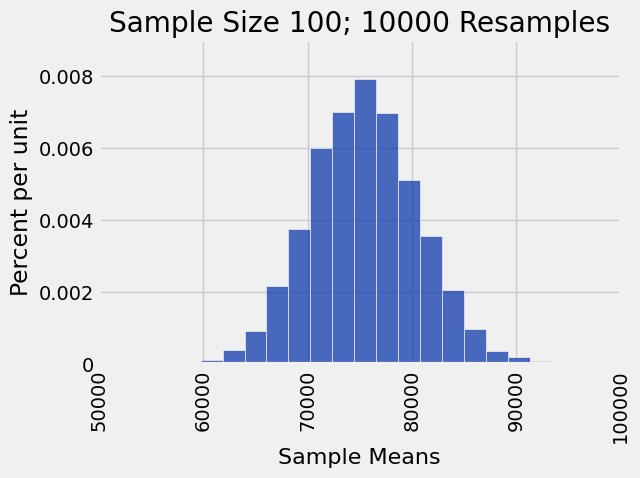

In [71]:
simulate_sample_mean(salaries, 'salary', 100, 10000)
plots.xlim(50000, 100000);
plots.ylim(0, 0.00009);

What did you notice about the distributions of sample means in the four histograms above? Discuss with your peers.


**Question 1.6.** Assign the variable `SD_of_sample_means` to the integer corresponding to your answer to the following question:

When I increase the number of _resamples_ that I take, for a _fixed_ sample size, the SD of my sample means will...

1. Increase
2. Decrease
3. Stay about the same
4. Vary widely


In [72]:
SD_of_sample_means = 3

**Question 1.7.** Let's think about how the relationships between population SD, sample SD, and SD of sample means change with varying sample size. Which of the following is true? Assign the variable `pop_vs_sample` to an array of integer(s) that correspond to true statement(s).

_Hint 1:_ The sample SD is different from the SD of sample means.

_Hint 2:_ [Chapter 14.5](https://inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html) might be helpful for answering this question.

1. Sample SD gets smaller with increasing sample size.
2. Sample SD gets larger with increasing sample size.
3. Sample SD becomes more consistent with population SD with increasing sample size.
4. SD of sample means gets smaller with increasing sample size.
5. SD of sample means gets larger with increasing sample size.
6. SD of sample means stays the same with increasing sample size.


In [73]:
pop_vs_sample = np.array([3, 4])

**Question 1.8.** Is there a relationship between the sample size and the standard deviation of the sample means? Assign `q1_8` to the number corresponding to the statement that answers this question.

_Hint:_ [Chapter 14.5](https://inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html) of the textbook may be helpful.

1. The SD of the sample means is inversely proportional to the square root of sample size.
2. The SD of the sample means is directly proportional to the square root of sample size.


In [74]:
q1_8 = 1

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [76]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab22(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab22(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab22(SSU)_files/
[NbConvertApp] Making directory ./lab22(SSU)_files
[NbConvertApp] Writing 78352 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 321177 bytes to DS/lab22(SSU).pdf
